Audio_1 original :
  Durée : 48.5s
  Max   : 1.0000
  Moy   : 0.0136

ATOMS3R brut :
  Durée : 45.5s
  Max   : 0.4211
  Moy   : 0.0063

ATOMS3R normalisé (identique librosa) :
  Max   : 1.0000
  Moy   : 0.0150


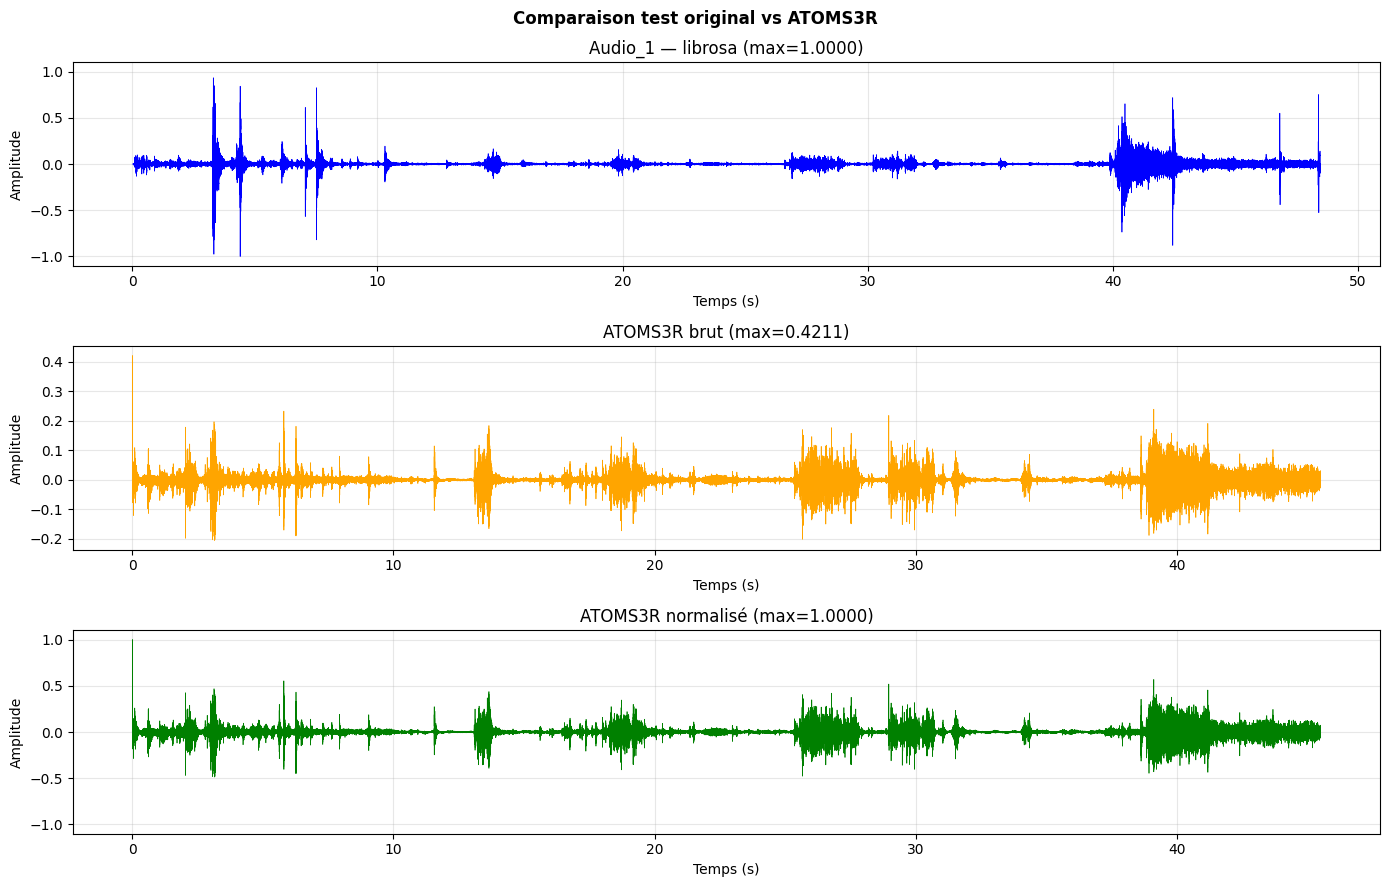


Graphique sauvegarde : comparaison_signaux.png


In [3]:
# ── Comparaison Audio_1 vs ATOMS3R brut ──────────────────────
import numpy as np
import librosa
import matplotlib.pyplot as plt
import soundfile as sf

# Charger Audio_1 original (pipeline entraînement)
y_orig, sr1 = sf.read(
    r'C:\Users\asalou\S7\stages7\project\emb_atom\test_ampl\test_amp\Audio_2.wav')
y_orig = y_orig.astype(np.float32)

# Charger signal ATOMS3R brut
y_atom, sr2 = sf.read(
    r'C:\Users\asalou\S7\stages7\project\emb_atom\test_ampl\test_amp\atoms3r_brut.wav')
y_atom = y_atom.astype(np.float32)

# Normaliser ATOMS3R comme librosa
y_atom_norm = y_atom / (np.max(np.abs(y_atom)) + 1e-9)

print(f"Audio_1 original :")
print(f"  Durée : {len(y_orig)/sr1:.1f}s")
print(f"  Max   : {np.max(np.abs(y_orig)):.4f}")
print(f"  Moy   : {np.mean(np.abs(y_orig)):.4f}")

print(f"\nATOMS3R brut :")
print(f"  Durée : {len(y_atom)/sr2:.1f}s")
print(f"  Max   : {np.max(np.abs(y_atom)):.4f}")
print(f"  Moy   : {np.mean(np.abs(y_atom)):.4f}")

print(f"\nATOMS3R normalisé (identique librosa) :")
print(f"  Max   : {np.max(np.abs(y_atom_norm)):.4f}")
print(f"  Moy   : {np.mean(np.abs(y_atom_norm)):.4f}")

# Zoom souhaité (en secondes)
zoom_start, zoom_end = 4.0, 4.15
# ── Affichage comparatif ──────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle('Comparaison test original vs ATOMS3R', fontweight='bold')

t1 = np.linspace(0, len(y_orig)/sr1, len(y_orig))
t2 = np.linspace(0, len(y_atom)/sr2, len(y_atom))

axes[0].plot(t1, y_orig, color='blue', lw=0.5)
axes[0].set_title(f'Audio_1 — librosa (max={np.max(np.abs(y_orig)):.4f})')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-1.1, 1.1)

axes[1].plot(t2, y_atom, color='orange', lw=0.5)
axes[1].set_title(f'ATOMS3R brut (max={np.max(np.abs(y_atom)):.4f})')
axes[1].set_ylabel('Amplitude')

axes[2].plot(t2, y_atom_norm, color='green', lw=0.5)
axes[2].set_title(f'ATOMS3R normalisé (max={np.max(np.abs(y_atom_norm)):.4f})')
axes[2].set_ylabel('Amplitude')
axes[2].set_ylim(-1.1, 1.1)

for ax in axes:
    ax.set_xlabel('Temps (s)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_signaux.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGraphique sauvegarde : comparaison_signaux.png")

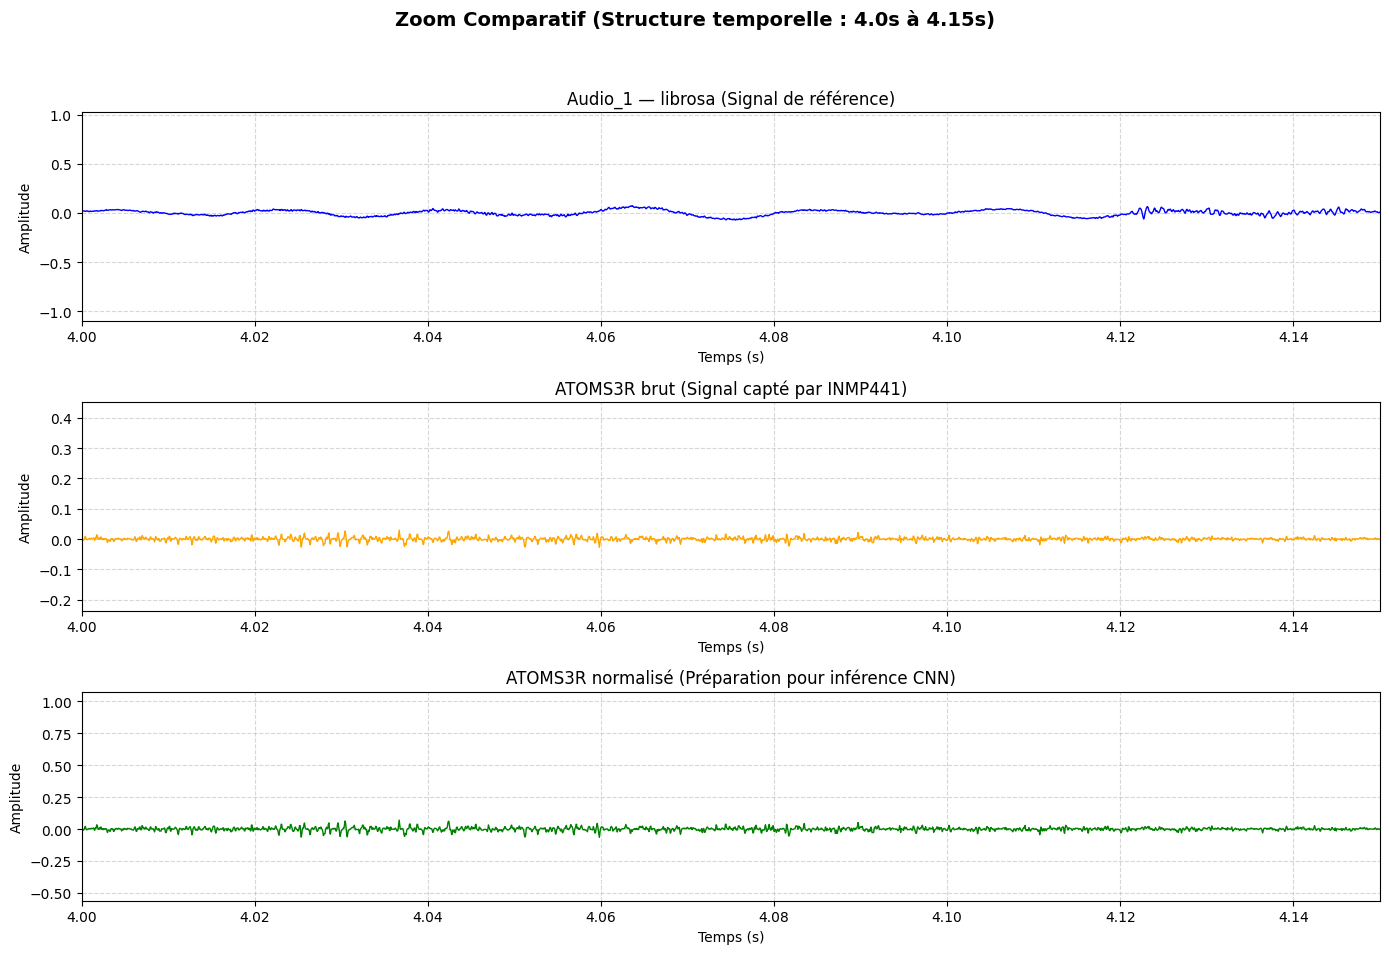


Zoom effectué entre 4.0s et 4.15s.
Fichier sauvegardé : zoom_comparaison_signaux.png


In [4]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import soundfile as sf
import os

# ── Configuration ───────────────────────────────────────────
sr1 = 16000  # Fréquence d'échantillonnage cible
path_m4a = r'C:\Users\asalou\S7\stages7\project\emb_atom\test_ampl\test_amp\Audio_2.wav'
path_wav = r'C:\Users\asalou\S7\stages7\project\emb_atom\test_ampl\test_amp\atoms3r_brut.wav'

# Zoom souhaité (en secondes)
zoom_start, zoom_end = 4.0, 4.15

# ── Chargement ──────────────────────────────────────────────
if not os.path.exists(path_m4a):
    print(f"❌ Erreur : Fichier m4a introuvable à {path_m4a}")
else:
    # Charger Audio_1 original (librosa)
    y_orig, _ = librosa.load(path_m4a, sr=sr1, mono=True)

    # Charger signal ATOMS3R brut
    y_atom, sr2 = sf.read(path_wav)
    y_atom = y_atom.astype(np.float32)

    # Normalisation ATOMS3R
    y_atom_norm = y_atom / (np.max(np.abs(y_atom)) + 1e-9)

    # ── Affichage comparatif avec ZOOM ───────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f'Zoom Comparatif (Structure temporelle : {zoom_start}s à {zoom_end}s)', fontsize=14, fontweight='bold')

    t1 = np.linspace(0, len(y_orig)/sr1, len(y_orig))
    t2 = np.linspace(0, len(y_atom)/sr2, len(y_atom))

    # Trace 1 : Original
    axes[0].plot(t1, y_orig, color='blue', lw=1)
    axes[0].set_title('Audio_1 — librosa (Signal de référence)')
    axes[0].set_ylabel('Amplitude')

    # Trace 2 : ATOMS3R Brut
    axes[1].plot(t2, y_atom, color='orange', lw=1)
    axes[1].set_title('ATOMS3R brut (Signal capté par INMP441)')
    axes[1].set_ylabel('Amplitude')

    # Trace 3 : ATOMS3R Normalisé
    axes[2].plot(t2, y_atom_norm, color='green', lw=1)
    axes[2].set_title('ATOMS3R normalisé (Préparation pour inférence CNN)')
    axes[2].set_ylabel('Amplitude')

    # Application du zoom et mise en forme
    for ax in axes:
        ax.set_xlim(zoom_start, zoom_end) # <--- LE ZOOM EST ICI
        ax.set_xlabel('Temps (s)')
        ax.grid(True, which='both', linestyle='--', alpha=0.5)
        # On ajuste l'ordonnée pour bien voir le signal zoomé
        ax.set_ylim(ax.get_ylim()) 

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('zoom_comparaison_signaux.png', dpi=150)
    plt.show()

    print(f"\nZoom effectué entre {zoom_start}s et {zoom_end}s.")
    print("Fichier sauvegardé : zoom_comparaison_signaux.png")

Silence (t=3s) — diff moy = 0.2824
Miction (t=15s) — diff moy = 0.2252
Chasse (t=35s) — diff moy = 0.2722


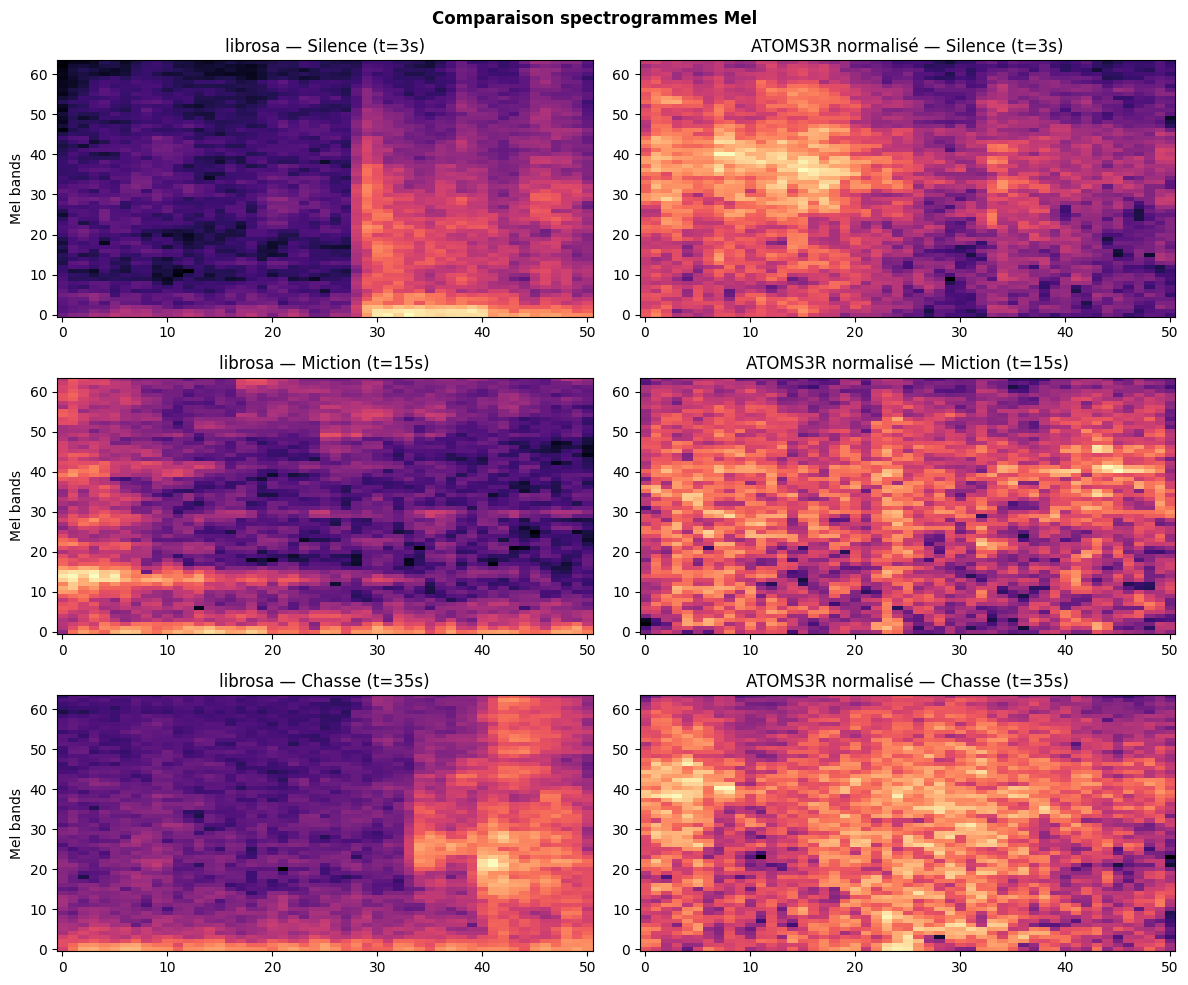

In [5]:
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

# Signal original librosa
y_orig, sr1 = librosa.load(
    r'C:\Users\asalou\S7\stages7\project\emb_atom\test_ampl\test_amp\Audio_2.wav',
    sr=16000, mono=True)

# Signal ATOMS3R brut → normaliser comme librosa
y_atom, _ = sf.read(
    r'C:\Users\asalou\S7\stages7\project\emb_atom\test_ampl\test_amp\atoms3r_brut.wav')
y_atom = y_atom.astype(np.float32)
y_atom_norm = y_atom / (np.max(np.abs(y_atom)) + 1e-9)

def mel_spec(y):
    mel = librosa.feature.melspectrogram(
        y=y.astype(float), sr=16000, n_mels=64,
        n_fft=512, hop_length=160, fmax=6000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mn, mx = mel_db.min(), mel_db.max()
    return (mel_db - mn) / (mx - mn + 1e-9)

# Comparer 3 moments : silence, miction, chasse
moments = [
    (3,  "Silence (t=3s)"),
    (15, "Miction (t=15s)"),
    (35, "Chasse (t=35s)"),
]

fig, axes = plt.subplots(len(moments), 2, figsize=(12, 10))
fig.suptitle('Comparaison spectrogrammes Mel', fontweight='bold')

for row, (t_s, titre) in enumerate(moments):
    idx = t_s * 16000
    seg_orig = y_orig[idx:idx+8000]
    seg_atom = y_atom_norm[idx:idx+8000]

    if len(seg_orig) < 8000 or len(seg_atom) < 8000:
        continue

    mel_o = mel_spec(seg_orig)
    mel_a = mel_spec(seg_atom)

    diff = np.mean(np.abs(mel_o - mel_a))
    print(f"{titre} — diff moy = {diff:.4f}")

    axes[row,0].imshow(mel_o, origin='lower', aspect='auto', cmap='magma')
    axes[row,0].set_title(f'librosa — {titre}')
    axes[row,0].set_ylabel('Mel bands')

    axes[row,1].imshow(mel_a, origin='lower', aspect='auto', cmap='magma')
    axes[row,1].set_title(f'ATOMS3R normalisé — {titre}')

plt.tight_layout()
plt.savefig('comparaison_mel_3moments.png', dpi=150)
plt.show()

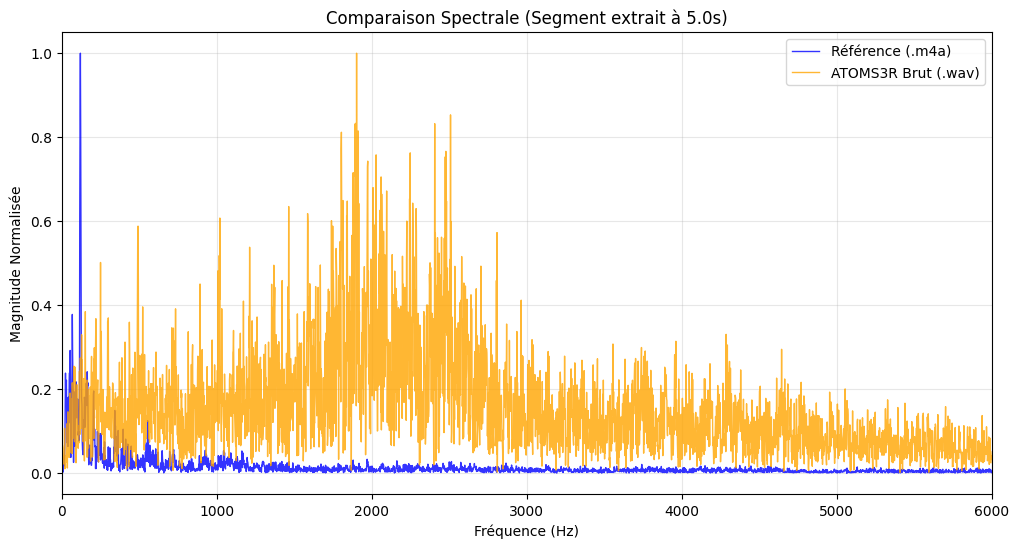


Analyse des écarts (Ratios d'énergie) :
-------------------------------------------------------
 100- 500 Hz | Ratio :     0.04x
 500-1000 Hz | Ratio :     0.86x
1000-2000 Hz | Ratio :     7.73x
2000-4000 Hz | Ratio :    14.33x
4000-6000 Hz | Ratio :     6.00x


In [6]:
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import os

# --- CONFIGURATION ---
path_m4a = r'C:\Users\asalou\S7\stages7\project\emb_atom\test_ampl\test_amp\Audio_2.wav'
path_wav = r'C:\Users\asalou\S7\stages7\project\emb_atom\test_ampl\test_amp\atoms3r_brut.wav'

try:
    # 1. Chargement des signaux (sr=16000Hz imposé par le modèle) [cite: 47, 66, 69, 72]
    y_orig, _ = librosa.load(path_m4a, sr=16000, mono=True)
    y_atom, _ = sf.read(path_wav)
    
    # Normalisation identique au pipeline de l'AtomS3R [-1.0, +1.0] [cite: 75, 290, 311]
    y_atom_norm = y_atom.astype(np.float32) / (np.max(np.abs(y_atom)) + 1e-9)

    # 2. Extraction sécurisée sur un fichier de 10s
    # On cible t=5s (5 * 16000 samples) pour être au milieu du fichier
    target_sample = 5 * 16000
    duration_samples = 8000 # Segment de 500ms 
    
    # Vérification des durées réelles
    start_orig = min(target_sample, len(y_orig) - duration_samples)
    start_atom = min(target_sample, len(y_atom_norm) - duration_samples)

    seg_orig = y_orig[start_orig : start_orig + duration_samples]
    seg_atom = y_atom_norm[start_atom : start_atom + duration_samples]

    # 3. Calcul de la FFT (Transformée de Fourier) [cite: 119, 290]
    fft_orig = np.abs(np.fft.rfft(seg_orig))
    fft_atom = np.abs(np.fft.rfft(seg_atom))
    freqs    = np.fft.rfftfreq(duration_samples, 1/16000)

    # Normalisation pour comparer la signature (la forme du spectre)
    fft_orig_n = fft_orig / (fft_orig.max() + 1e-10)
    fft_atom_n = fft_atom / (fft_atom.max() + 1e-10)

    # 4. Affichage du graphique
    plt.figure(figsize=(12, 6))
    plt.plot(freqs, fft_orig_n, color='blue', lw=1, label='Référence (.m4a)', alpha=0.8)
    plt.plot(freqs, fft_atom_n, color='orange', lw=1, label='ATOMS3R Brut (.wav)', alpha=0.8)
    
    plt.xlabel('Fréquence (Hz)')
    plt.ylabel('Magnitude Normalisée')
    plt.title(f'Comparaison Spectrale (Segment extrait à {start_orig/16000:.1f}s)')
    plt.xlim(0, 6000) # Limite de l'IA (Mel spectrogram) [cite: 118, 141]
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Enregistrement pour ta Slide 26 [cite: 376, 381, 384]
    plt.savefig('comparaison_spectre_10s.png', dpi=200, bbox_inches='tight')
    plt.show()

    # 5. Calcul des ratios (Justification des coefficients itératifs) [cite: 394, 400, 403]
    bandes = [(100,500), (500,1000), (1000,2000), (2000,4000), (4000,6000)]
    print("\nAnalyse des écarts (Ratios d'énergie) :")
    print("-" * 55)
    for f1, f2 in bandes:
        mask   = (freqs >= f1) & (freqs < f2)
        e_orig = np.mean(fft_orig[mask]**2)
        e_atom = np.mean(fft_atom[mask]**2)
        ratio  = e_atom / (e_orig + 1e-10)
        print(f"{f1:4}-{f2:4} Hz | Ratio : {ratio:8.2f}x")

except Exception as e:
    print(f"❌ Erreur lors de l'analyse : {e}")

C:\Users\asalou\AppData\Local\Temp\ipykernel_8604\1949414957.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  y_orig, _ = librosa.load(path_m4a, sr=16000, mono=True)


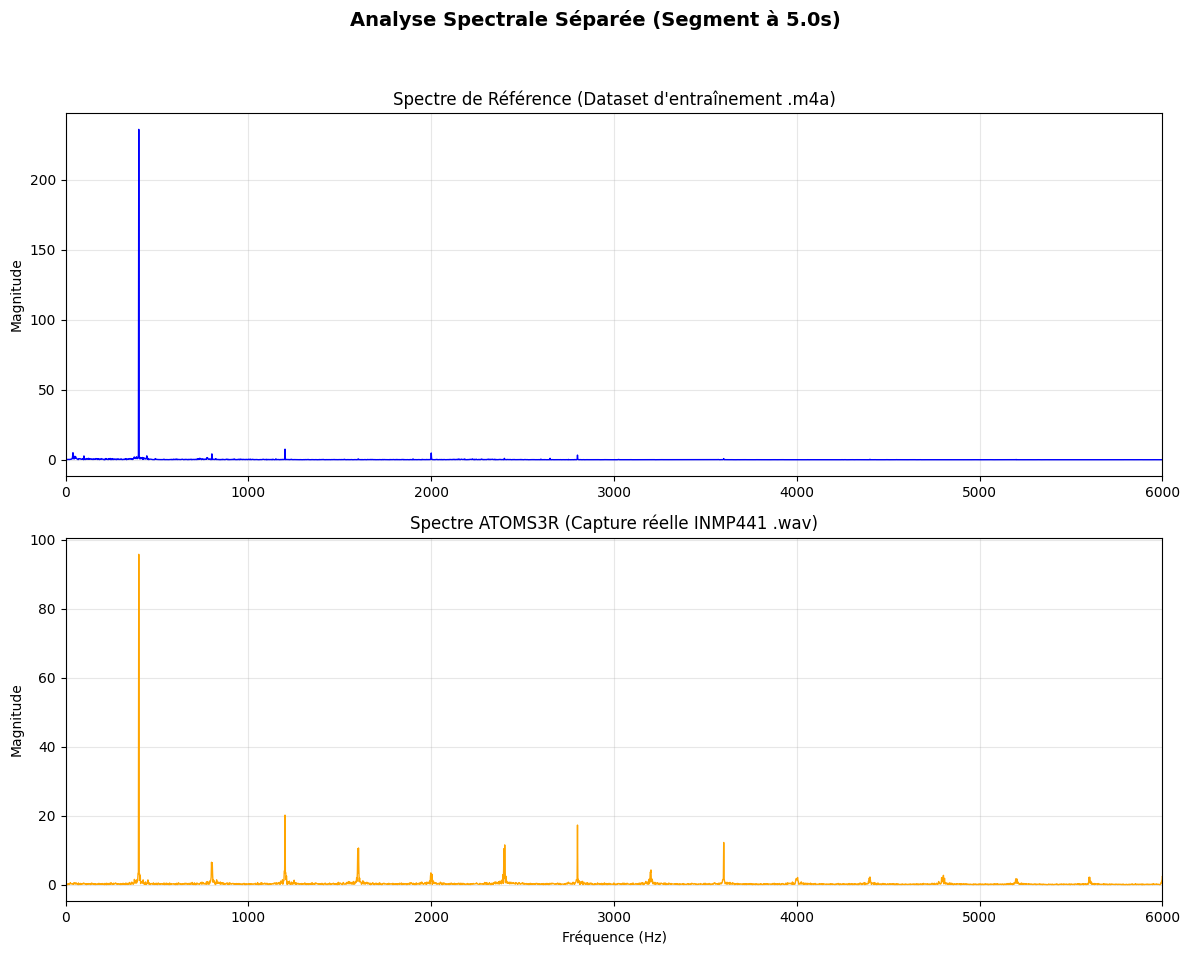


Énergie par bande fréquentielle :
-------------------------------------------------------
 100- 500 Hz | Ratio :     0.17x
 500-1000 Hz | Ratio :     3.69x
1000-2000 Hz | Ratio :    12.93x
2000-4000 Hz | Ratio :    20.37x
4000-6000 Hz | Ratio :   151.52x


In [24]:
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import os

# --- CONFIGURATION ---
path_m4a = r'C:\Users\asalou\S7\stages7\project\emb_atom\test_ampl\test_amp\test.m4a'
path_wav = r'C:\Users\asalou\S7\stages7\project\emb_atom\test_ampl\test_amp\atoms3r_brut.wav'

try:
    # 1. Chargement des signaux (sr=16kHz requis pour le modèle) [cite: 47, 72]
    y_orig, _ = librosa.load(path_m4a, sr=16000, mono=True)
    y_atom, _ = sf.read(path_wav)
    
    # Normalisation identique au pipeline de l'AtomS3R [-1.0, +1.0] [cite: 75]
    y_atom_norm = y_atom.astype(np.float32) / (np.max(np.abs(y_atom)) + 1e-9)

    # 2. Extraction sécurisée (cible t=5s pour un fichier de 10s)
    target_sample = 5 * 16000
    duration_samples = 8000 # Segment de 500ms [cite: 49, 78]
    
    start_orig = min(target_sample, len(y_orig) - duration_samples)
    start_atom = min(target_sample, len(y_atom_norm) - duration_samples)

    seg_orig = y_orig[start_orig : start_orig + duration_samples]
    seg_atom = y_atom_norm[start_atom : start_atom + duration_samples]

    # 3. Calcul de la FFT
    fft_orig = np.abs(np.fft.rfft(seg_orig))
    fft_atom = np.abs(np.fft.rfft(seg_atom))
    freqs    = np.fft.rfftfreq(duration_samples, 1/16000)

    # 4. Affichage SÉPARÉ (2 subplots)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    fig.suptitle(f'Analyse Spectrale Séparée (Segment à {start_orig/16000:.1f}s)', fontsize=14, fontweight='bold')

    # Graphique 1 : Référence librosa
    ax1.plot(freqs, fft_orig, color='blue', lw=1)
    ax1.set_title('Spectre de Référence (Dataset d\'entraînement .m4a)')
    ax1.set_ylabel('Magnitude')
    ax1.set_xlim(0, 6000)
    ax1.grid(True, alpha=0.3)

    # Graphique 2 : ATOMS3R
    ax2.plot(freqs, fft_atom, color='orange', lw=1)
    ax2.set_title('Spectre ATOMS3R (Capture réelle INMP441 .wav)')
    ax2.set_ylabel('Magnitude')
    ax2.set_xlim(0, 6000)
    ax2.grid(True, alpha=0.3)

    plt.xlabel('Fréquence (Hz)')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Enregistrement de l'image
    plt.savefig('spectres_separes_miction.png', dpi=200)
    plt.show()

    # 5. Calcul des ratios (Justification des coefficients itératifs) [cite: 400]
    bandes = [(100,500), (500,1000), (1000,2000), (2000,4000), (4000,6000)]
    print("\nÉnergie par bande fréquentielle :")
    print("-" * 55)
    for f1, f2 in bandes:
        mask   = (freqs >= f1) & (freqs < f2)
        e_orig = np.mean(fft_orig[mask]**2)
        e_atom = np.mean(fft_atom[mask]**2)
        ratio  = e_atom / (e_orig + 1e-10)
        print(f"{f1:4}-{f2:4} Hz | Ratio : {ratio:8.2f}x")

except Exception as e:
    print(f"❌ Erreur lors de l'analyse : {e}")